
Training Model 1
Hidden Layers: (1024, 512, 256)
Activation: relu
Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 30ms/step - accuracy: 0.3187 - loss: 1.8791
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 31ms/step - accuracy: 0.4064 - loss: 1.6558
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 30ms/step - accuracy: 0.4384 - loss: 1.5671
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 30ms/step - accuracy: 0.4578 - loss: 1.5115
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.4781 - loss: 1.4631
Test Loss: 1.48203706741333
Test Accuracy: 0.47609999775886536

Training Model 2
Hidden Layers: (1024, 512, 256)
Activation: tanh
Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.2297 - loss: 2.0428
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 31ms/step - accuracy: 0.2784 - loss: 1.9428
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 30ms/step - accuracy: 0.2930 - loss: 1.9160
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 30ms/step - accuracy: 0.2921 - loss: 1.9130
Epoch 5/5
782/782 ━━

782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.2761 - loss: 1.9745
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3361 - loss: 1.8334
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3461 - loss: 1.8026
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3617 - loss: 1.7674
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3701 - loss: 1.7484
Test Loss: 1.714001178741455
Test Accuracy: 0.38589999079704285

Training Model 12
Hidden Layers: (128, 64, 32)
Activation: sigmoid
Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.2204 - loss: 2.0814
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3174 - loss: 1.8765
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3479 - loss: 1.7978
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3668 - loss: 1.7466
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3776 - loss: 1.7145
Test Loss: 1.764755606651306

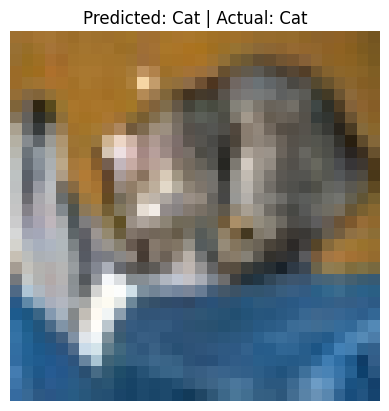

In [3]:

import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# 1. Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# 2. Normalize images
x_train = x_train / 255.0
x_test = x_test / 255.0

# 3. One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# 4. CIFAR-10 class names
class_names = [
    'Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
    'Dog', 'Frog', 'Horse', 'Ship', 'Truck'
]

# 5. Create FFNN with THREE hidden layers
def create_model(units, activation):
    model = Sequential([
        Flatten(input_shape=(32, 32, 3)),

        Dense(units[0], activation=activation),
        Dense(units[1], activation=activation),
        Dense(units[2], activation=activation),

        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


# 6. Hyperparameters
hidden_units_list = [
    (1024,512,256),
    (512,256,128),
    (256, 128, 64),
    (128, 64, 32)
]

# Test ALL three activation functions
activation_list = ['relu', 'tanh', 'sigmoid']


# 7. Store results
results = []

best_accuracy = 0
best_model = None
best_config = None


# 8. Train all configurations
model_number = 1

for units in hidden_units_list:
    for activation in activation_list:

        print("\n================================")
        print("Training Model", model_number)
        print("Hidden Layers:", units)
        print("Activation:", activation)
        print("================================")

        model = create_model(units, activation)

        # Train model
        model.fit(
            x_train,
            y_train,
            epochs=5,
            batch_size=64,
            verbose=1
        )

        # Evaluate model
        loss, accuracy = model.evaluate(
            x_test,
            y_test,
            verbose=0
        )

        print("Test Loss:", loss)
        print("Test Accuracy:", accuracy)

        # Store results
        results.append({
            "Model": model_number,
            "Hidden Layers": units,
            "Activation": activation,
            "Test Loss": loss,
            "Test Accuracy": accuracy
        })

        # Find best model
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_model = model
            best_config = (units, activation)

        model_number += 1


# 9. Display ALL model configurations
print("\n\n==============================================")
print("        CONFIGURATION OF ALL MODELS")
print("==============================================")

for result in results:
    print("\nModel", result["Model"])
    print("Hidden Layers :", result["Hidden Layers"])
    print("Activation    :", result["Activation"])
    print("Test Loss     :", round(result["Test Loss"], 4))
    print("Test Accuracy :", round(result["Test Accuracy"], 4))


# 10. Display best model
print("\n\n==============================================")
print("              BEST MODEL")
print("==============================================")

print("Hidden Layers :", best_config[0])
print("Activation    :", best_config[1])
print("Best Accuracy :", round(best_accuracy, 4))


# 11. Predict one test image
index = 0

prediction = best_model.predict(
    x_test[index:index+1],
    verbose=0
)

predicted_class = prediction.argmax()
actual_class = y_test[index].argmax()

print("\nPredicted Label:", class_names[predicted_class])
print("Actual Label   :", class_names[actual_class])


# 12. Display the image
plt.imshow(x_test[index])
plt.title(
    "Predicted: " + class_names[predicted_class] +
    " | Actual: " + class_names[actual_class]
)
plt.axis('off')
plt.show()